In [1]:
%pip install statsmodels
%pip install matplotlib
%pip install pandas
%pip install statsmodels

Defaulting to user installation because normal site-packages is not writeableNote: you may need to restart the kernel to use updated packages.

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [552]:
import pandas as pd
import requests
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from statsmodels.tsa.statespace.sarimax import SARIMAX
import numpy as np
from sklearn.linear_model import LinearRegression

In [151]:
df= pd.read_csv(r"C:\Users\Ratiba Zaid\Downloads\df_values.csv", sep=',')

In [152]:
df.head()

,Unnamed: 0,Year_Month,Province,Average NO2 Value,Average PM2.5 Value,Average PM10 Value,area_km2,vehicles_tot
0,0,1990-01-01,Drenthe,29,NaN,NaN,0.0,11755668
1,1,1990-01-01,Flevoland,33,NaN,NaN,0.0,12550586
2,2,1990-01-01,Friesland,28,NaN,NaN,0.0,14990976
3,3,1990-01-01,Gelderland,39,NaN,NaN,0.0,43979534
4,4,1990-01-01,Groningen,28,NaN,NaN,0.0,11936457


In [147]:
print(df.columns)

Index(['Unnamed: 0', 'Year_Month', 'Province', 'Average NO2 Value',
       'Average PM2.5 Value', 'Average PM10 Value', 'area_km2',
       'vehicles_tot'],
      dtype='object')


Before the prediction, it is important to first visualize the patterns of each pollution type over the year 2016 until 2025. The reason why we do not consider the year 1990 anymore is because it is only represented in the ... attribute. We therefore choose to do prediction from the year 2016. See code below for the visualization. 

In [148]:
df['Year_Month'] = pd.to_datetime(df['Year_Month'])
df.set_index('Year_Month', inplace=True)
dffilter=df[df.index>='2016-01-01']
print(dffilter)

            Unnamed: 0       Province  Average NO2 Value  Average PM2.5 Value  \
Year_Month                                                                      
2016-01-01         144        Drenthe                 17                  NaN   
2016-01-01         145      Flevoland                 21                  NaN   
2016-01-01         146      Friesland                 16                 17.0   
2016-01-01         147     Gelderland                 27                 12.0   
2016-01-01         148      Groningen                 26                 19.0   
...                ...            ...                ...                  ...   
2024-12-01        1435  Noord-Holland                 20                 10.0   
2024-12-01        1436     Overijssel                  9                  6.0   
2024-12-01        1437        Utrecht                 16                 11.0   
2024-12-01        1438        Zeeland                 10                  NaN   
2024-12-01        1439   Zui

We know are going to visualize the polution values over each year by using the mean function. 

In [53]:
print(dffilter.columns)

Index(['Unnamed: 0', 'Province', 'Average NO2 Value', 'Average PM2.5 Value',
       'Average PM10 Value', 'area_km2', 'vehicles_tot'],
      dtype='object')


In [399]:
NO2meanraw_year= dffilter['Average NO2 Value'].resample('YE').mean() #take the mean of each year at the end
dfNO2meanraw=NO2meanraw_year.reset_index()
dfNO2meanraw.columns=['Year', 'Average NO2 Value'] #create dfNO2mean dataframe with year and avg NO2 as the column
dfNO2meanraw['Year']=dfNO2meanraw['Year'].dt.year  #extract the dates into years
print(dfNO2meanraw)

PM25meanraw_year= dffilter['Average PM2.5 Value'].resample('YE').mean() #take the mean of each year at the end
dfPM25meanraw=PM25meanraw_year.reset_index()
dfPM25meanraw.columns=['Year', 'Average PM2.5 Value'] #create dfPM25mean dataframe with year and avg PM2.5 as the column
dfPM25meanraw['Year']=dfPM25meanraw['Year'].dt.year #extract the dates into years
print("\n",dfPM25meanraw)

PM10meanraw_year= dffilter['Average PM10 Value'].resample('YE').mean() #take the mean of each year at the end
dfPM10meanraw=PM10meanraw_year.reset_index()
dfPM10meanraw.columns=['Year', 'Average PM10 Value'] #create dfPM10mean dataframe with year and avg PM10 as the column
dfPM10meanraw['Year']=dfPM10meanraw['Year'].dt.year #extract the dates into years
print("\n",dfPM10meanraw)

   Year  Average NO2 Value
0  2016          19.472222
1  2017          18.805556
2  2018          18.291667
3  2019          17.229167
4  2020          14.201389
5  2021          13.916667
6  2022          13.930556
7  2023          11.708333
8  2024          11.270833

    Year  Average PM2.5 Value
0  2016            10.712963
1  2017            10.814815
2  2018            11.731481
3  2019            10.231481
4  2020             8.657407
5  2021             9.185185
6  2022             9.000000
7  2023             7.740741
8  2024             7.982906

    Year  Average PM10 Value
0  2016           18.180556
1  2017           18.208333
2  2018           19.583333
3  2019           17.958333
4  2020           16.027778
5  2021           15.958333
6  2022           16.750000
7  2023           15.062500
8  2024           14.395833


In [557]:
PM10meanrawprov_year= dffilter.groupby('Province')['Average PM10 Value'].resample('YE').mean() #take the mean of each year at the end
dfPM10meanrawprov=PM10meanrawprov_year.reset_index()
dfPM10meanrawprov.columns=['Province','Year', 'Average PM10 Value'] #create dfPM10mean dataframe with year and avg PM10 as the column
dfPM10meanrawprov['Year']=dfPM10meanrawprov['Year'].dt.year #extract the dates into years
print("\n",dfPM10meanrawprov)

NO2meanrawprov_year= dffilter.groupby('Province')['Average NO2 Value'].resample('YE').mean() #take the mean of each year at the end
dfNO2meanrawprov=NO2meanrawprov_year.reset_index()
dfNO2meanrawprov.columns=['Province','Year', 'Average NO2 Value'] #create dfPM10mean dataframe with year and avg PM10 as the column
dfNO2meanrawprov['Year']=dfNO2meanrawprov['Year'].dt.year #extract the dates into years
print("\n",dfNO2meanrawprov)

PM25meanrawprov_year= dffilter.groupby('Province')['Average PM2.5 Value'].resample('YE').mean() #take the mean of each year at the end
dfPM25meanrawprov=PM25meanrawprov_year.reset_index()
dfPM25meanrawprov.columns=['Province','Year', 'Average PM2.5 Value'] #create dfPM10mean dataframe with year and avg PM10 as the column
dfPM25meanrawprov['Year']=dfPM25meanrawprov['Year'].dt.year #extract the dates into years
print("\n",dfPM25meanrawprov)


          Province  Year  Average PM10 Value
0         Drenthe  2016           15.250000
1         Drenthe  2017           14.750000
2         Drenthe  2018           15.833333
3         Drenthe  2019           15.833333
4         Drenthe  2020           13.416667
..            ...   ...                 ...
103  Zuid-Holland  2020           18.416667
104  Zuid-Holland  2021           18.666667
105  Zuid-Holland  2022           18.750000
106  Zuid-Holland  2023           17.000000
107  Zuid-Holland  2024           16.333333

[108 rows x 3 columns]

          Province  Year  Average NO2 Value
0         Drenthe  2016          10.750000
1         Drenthe  2017          10.500000
2         Drenthe  2018          11.083333
3         Drenthe  2019          10.500000
4         Drenthe  2020           8.666667
..            ...   ...                ...
103  Zuid-Holland  2020          22.916667
104  Zuid-Holland  2021          22.666667
105  Zuid-Holland  2022          22.666667
106  Zuid-Holl

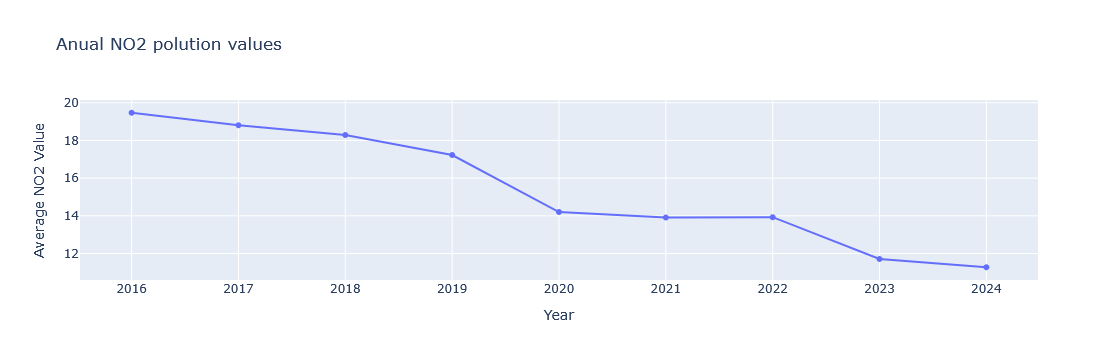

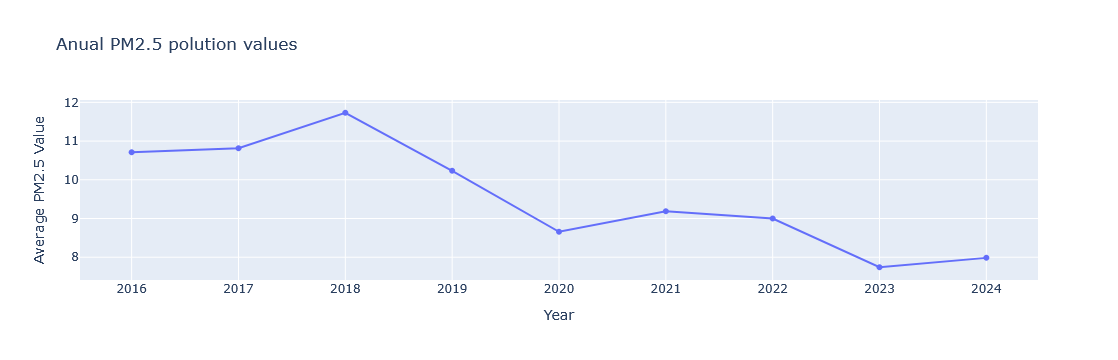

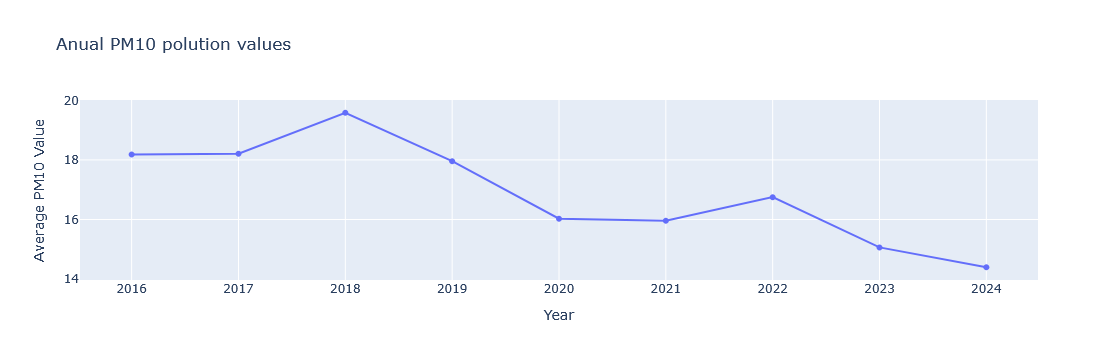

In [561]:
#linechart avg NO2 polution value from 2016-2014
figavgNO2 = px.line(dfNO2meanraw, x="Year", y="Average NO2 Value", markers=True, title="Anual NO2 polution values")
figavgNO2.show()

#linechart avg PM2.5 polution value from 2016-2014
figavgPM25 = px.line(dfPM25meanraw, x="Year", y="Average PM2.5 Value", markers=True, title="Anual PM2.5 polution values")
figavgPM25.show()

#linechart avg PM10 polution value from 2016-2014
figavgPM10 = px.line(dfPM10meanraw, x="Year", y="Average PM10 Value", markers=True, title="Anual PM10 polution values")
figavgPM10.show()

In the following section, we will start using the preprocessed data set for the prediction instead of the dataset used for the plots above. We standardized the data (mean of 0, SD of 1) in order to transform the data into the same scale. This helps to prevent the impact of the amount of car values to dominate the predictions.

### SARIMAX
We first used SARIMAX for the prediction part. SARIMAX is a ML algorithm wich predicts values regarding timeseries considering seasonal patterns. It uses autoregression which means that it uses historical timeseries to predict [1], in our case, future polution values. The reason why we used SARIMAX is because it also considers exogenous variables which could influence the prediction of the polution values. The exogenous variables in our case are the 'area_km2' and'vehicles_tot'.

[1] https://zerotomastery.io/blog/arima-sarima-sarimax-explained/#SARIMAX-vs-SARIMA

In [562]:
dfcleaned= pd.read_csv(r"C:\Users\Ratiba Zaid\Downloads\df_prediction.csv", sep=',')

dfcleaned.head()

,Unnamed: 0,Year_Month,Province,Average NO2 Value,Average PM2.5 Value,Average PM10 Value,area_km2_st,vehicles_tot
0,0,1990-01-01,Drenthe,1.324917,NaN,NaN,0.0,-1.052171
1,1,1990-01-01,Flevoland,1.764091,NaN,NaN,0.0,-0.952434
2,2,1990-01-01,Friesland,1.215124,NaN,NaN,0.0,-0.681598
3,3,1990-01-01,Gelderland,2.422852,NaN,NaN,0.0,0.958949
4,4,1990-01-01,Groningen,1.215124,NaN,NaN,0.0,-1.028907


In [563]:
dfcleaned['Year_Month'] = pd.to_datetime(dfcleaned['Year_Month'])
dfcleaned.set_index('Year_Month', inplace=True)
dffiltercleaned=dfcleaned[dfcleaned.index>='2016-01-01']
print(dffiltercleaned)

            Unnamed: 0       Province  Average NO2 Value  Average PM2.5 Value  \
Year_Month                                                                      
2016-01-01         144        Drenthe           0.007396                  NaN   
2016-01-01         145      Flevoland           0.446570                  NaN   
2016-01-01         146      Friesland          -0.102398             2.008901   
2016-01-01         147     Gelderland           1.105330             0.661116   
2016-01-01         148      Groningen           0.995537             2.548015   
...                ...            ...                ...                  ...   
2024-12-01        1435  Noord-Holland           0.336776             0.122001   
2024-12-01        1436     Overijssel          -0.870952            -0.956227   
2024-12-01        1437        Utrecht          -0.102398             0.391558   
2024-12-01        1438        Zeeland          -0.761158                  NaN   
2024-12-01        1439   Zui

In [564]:
NO2mean_year= dffiltercleaned[['Average NO2 Value', 'area_km2_st', 'vehicles_tot']].resample('YE').mean() #take the mean of each year at the end
dfNO2mean=NO2mean_year.reset_index()
dfNO2mean.columns=['Year', 'Average NO2 Value', 'area_km2_st', 'vehicles_tot'] #create dfNO2mean dataframe with year and avg NO2 as the column
dfNO2mean['Year']=dfNO2mean['Year'].dt.year  #extract the dates into years
print(dfNO2mean)

PM25mean_year= dffiltercleaned[['Average PM2.5 Value', 'area_km2_st', 'vehicles_tot']].resample('YE').mean() #take the mean of each year at the end
dfPM25mean=PM25mean_year.reset_index()
dfPM25mean.columns=['Year', 'Average PM2.5 Value', 'area_km2_st', 'vehicles_tot'] #create dfPM25mean dataframe with year and avg PM2.5 as the column
dfPM25mean['Year']=dfPM25mean['Year'].dt.year #extract the dates into years
print("\n",dfPM25mean)

PM10mean_year= dffiltercleaned[['Average PM10 Value', 'area_km2_st', 'vehicles_tot']].resample('YE').mean() #take the mean of each year at the end
dfPM10mean=PM25mean_year.reset_index()
dfPM10mean.columns=['Year', 'Average PM10 Value', 'area_km2_st', 'vehicles_tot'] #create dfPM10mean dataframe with year and avg PM10 as the column
dfPM10mean['Year']=dfPM10mean['Year'].dt.year #extract the dates into years
print("\n",dfPM10mean)

   Year  Average NO2 Value  area_km2_st  vehicles_tot
0  2016           0.278830     0.000000 -1.369275e-15
1  2017           0.205634     0.000000 -1.369275e-15
2  2018           0.149212     0.000000 -1.369275e-15
3  2019           0.032557     0.000000 -1.369275e-15
4  2020          -0.299873    -0.058617 -1.369275e-15
5  2021          -0.331134     0.008647 -1.369275e-15
6  2022          -0.329609     0.008647 -1.369275e-15
7  2023          -0.573595     0.008647 -1.369275e-15
8  2024          -0.621629     0.008647 -1.369275e-15

    Year  Average PM2.5 Value  area_km2_st  vehicles_tot
0  2016             0.314186     0.000000 -1.369275e-15
1  2017             0.341641     0.000000 -1.369275e-15
2  2018             0.588735     0.000000 -1.369275e-15
3  2019             0.184399     0.000000 -1.369275e-15
4  2020            -0.239904    -0.058617 -1.369275e-15
5  2021            -0.097638     0.008647 -1.369275e-15
6  2022            -0.147556     0.008647 -1.369275e-15
7  2023   

In [565]:
PM10meanprov_year= dffiltercleaned.groupby('Province')[['Average PM10 Value', 'area_km2_st', 'vehicles_tot']].resample('YE').mean() #take the mean of each year at the end
dfPM10meanprov=PM10meanprov_year.reset_index()
dfPM10meanprov.columns=['Province', 'Year','Average PM10 Value', 'area_km2_st', 'vehicles_tot'] #create dfPM10mean dataframe with year and avg PM10 as the column
dfPM10meanprov['Year']=dfPM10meanprov['Year'].dt.year #extract the dates into years
print("\n",dfPM10meanprov)

NO2meanprov_year= dffiltercleaned.groupby('Province')[['Average NO2 Value', 'area_km2_st', 'vehicles_tot']].resample('YE').mean() #take the mean of each year at the end
dfNO2meanprov=NO2meanprov_year.reset_index()
dfNO2meanprov.columns=['Province', 'Year','Average NO2 Value', 'area_km2_st', 'vehicles_tot'] #create dfPM10mean dataframe with year and avg PM10 as the column
dfNO2meanprov['Year']=dfNO2meanprov['Year'].dt.year #extract the dates into years
print("\n",dfNO2meanprov)

PM25meanprov_year= dffiltercleaned.groupby('Province')[['Average PM2.5 Value', 'area_km2_st', 'vehicles_tot']].resample('YE').mean() #take the mean of each year at the end
dfPM25meanprov=PM25meanprov_year.reset_index()
dfPM25meanprov.columns=['Province', 'Year','Average PM2.5 Value', 'area_km2_st', 'vehicles_tot'] #create dfPM10mean dataframe with year and avg PM10 as the column
dfPM25meanprov['Year']=dfPM25meanprov['Year'].dt.year #extract the dates into years
print("\n",dfPM25meanprov)


          Province  Year  Average PM10 Value  area_km2_st  vehicles_tot
0         Drenthe  2016           -0.381475     0.000000     -1.052171
1         Drenthe  2017           -0.496879     0.000000     -1.052171
2         Drenthe  2018           -0.246837     0.000000     -1.052171
3         Drenthe  2019           -0.246837     0.000000     -1.052171
4         Drenthe  2020           -0.804624     0.000000     -1.052171
..            ...   ...                 ...          ...           ...
103  Zuid-Holland  2020            0.349418     0.976009      1.487082
104  Zuid-Holland  2021            0.407120     0.976009      1.487082
105  Zuid-Holland  2022            0.426354     0.976009      1.487082
106  Zuid-Holland  2023            0.022440     0.976009      1.487082
107  Zuid-Holland  2024           -0.131433     0.976009      1.487082

[108 rows x 5 columns]

          Province  Year  Average NO2 Value  area_km2_st  vehicles_tot
0         Drenthe  2016          -0.678813     0.0

According to these findings, we came to the conclusion that it is more meaningful to use the raw data instead of the preprocessed data. When analyzing the data above, we came to the following conclusions:
- The predicted values are not meaningful since it is highly influence by the scale of the standardized data. To get some more meaningful insights we will use the standardized 'area_km2_st', 'vehicles_tot' values and the normal poluttion values. 
- we will not use k cross validations since we currently are using data linked to timeseries. The issue with k cross validation is that it will randomly put the data into train and test samples.
- We also considered using window partitioning. In this case the sequence of the data will be respected. However, since we only have 8 datapoints to train and test our data on, we have chosen to not use any train and test data sets to reduce overfitting.  

In [566]:
df= pd.read_csv(r"C:\Users\Ratiba Zaid\Downloads\df_values.csv", sep=',')
df['Year_Month'] = pd.to_datetime(df['Year_Month'])
df.set_index('Year_Month', inplace=True)
dffilter=df[df.index>='2016-01-01']
print(dffilter)

            Unnamed: 0       Province  Average NO2 Value  Average PM2.5 Value  \
Year_Month                                                                      
2016-01-01         144        Drenthe                 17                  NaN   
2016-01-01         145      Flevoland                 21                  NaN   
2016-01-01         146      Friesland                 16                 17.0   
2016-01-01         147     Gelderland                 27                 12.0   
2016-01-01         148      Groningen                 26                 19.0   
...                ...            ...                ...                  ...   
2024-12-01        1435  Noord-Holland                 20                 10.0   
2024-12-01        1436     Overijssel                  9                  6.0   
2024-12-01        1437        Utrecht                 16                 11.0   
2024-12-01        1438        Zeeland                 10                  NaN   
2024-12-01        1439   Zui

## Parameter explanation
- enforce_stationarity=False ->
- enforce_invertibility=False ->

[2] https://www.statsmodels.org/devel/generated/statsmodels.tsa.statespace.sarimax.SARIMAX.html

In [567]:
print(dfNO2mean)

   Year  Average NO2 Value  area_km2_st  vehicles_tot
0  2016           0.278830     0.000000 -1.369275e-15
1  2017           0.205634     0.000000 -1.369275e-15
2  2018           0.149212     0.000000 -1.369275e-15
3  2019           0.032557     0.000000 -1.369275e-15
4  2020          -0.299873    -0.058617 -1.369275e-15
5  2021          -0.331134     0.008647 -1.369275e-15
6  2022          -0.329609     0.008647 -1.369275e-15
7  2023          -0.573595     0.008647 -1.369275e-15
8  2024          -0.621629     0.008647 -1.369275e-15


In [568]:
NO2meanraw_year= dfNO2meanraw['Average NO2 Value']
exogenous_data=dfNO2mean[['area_km2_st','vehicles_tot']]

# Define SARIMAX model parameters
p = 1  # Autoregressive order
d = 1  # Differencing order
q = 1  # Moving average order
seasonal_order = (0, 0, 0, 0)  # seasonal parameters (P, D, Q, S)
# Fit SARIMAX model
model = SARIMAX(NO2meanraw_year, order=(p, d, q), seasonal_order=seasonal_order, exog=exogenous_data, enforce_stationarity=False, enforce_invertibility=False)
results = model.fit()
print(results.summary())

                               SARIMAX Results                                
Dep. Variable:      Average NO2 Value   No. Observations:                    9
Model:               SARIMAX(1, 1, 1)   Log Likelihood                  -8.193
Date:                Thu, 06 Nov 2025   AIC                             26.387
Time:                        21:15:47   BIC                             25.345
Sample:                             0   HQIC                            22.219
                                  - 9                                         
Covariance Type:                  opg                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
area_km2_st     20.9968     11.525      1.822      0.068      -1.592      43.586
vehicles_tot          0        nan        nan        nan         nan         nan
ar.L1            0.9964      0.221      4.51

In [569]:
print(exogenous_data)

   area_km2_st  vehicles_tot
0     0.000000 -1.369275e-15
1     0.000000 -1.369275e-15
2     0.000000 -1.369275e-15
3     0.000000 -1.369275e-15
4    -0.058617 -1.369275e-15
5     0.008647 -1.369275e-15
6     0.008647 -1.369275e-15
7     0.008647 -1.369275e-15
8     0.008647 -1.369275e-15


In [570]:
forecast = results.predict(start=dfNO2meanraw['Year'].index[0], end=dfNO2meanraw['Year'].index[-1],exog=exogenous_data)
print(forecast)

0     0.000000
1    29.173319
2    18.141291
3    17.704438
4    15.256562
5    14.614556
6    12.784030
7    12.988957
8    10.591780
Name: predicted_mean, dtype: float64


In [571]:
pred4years_exog = exogenous_data[-6:]  #assumption values for the next for years
pred4years = results.get_forecast(steps=6, exog=pred4years_exog)
forecast_index = pd.date_range(start=dfNO2meanraw['Year'].index[-1] , periods=6, freq='YE')
print(forecast_index)

DatetimeIndex(['1970-12-31 00:00:00.000000008',
               '1971-12-31 00:00:00.000000008',
               '1972-12-31 00:00:00.000000008',
               '1973-12-31 00:00:00.000000008',
               '1974-12-31 00:00:00.000000008',
               '1975-12-31 00:00:00.000000008'],
              dtype='datetime64[ns]', freq='YE-DEC')


In [572]:
print(dfNO2meanraw['Year'])

0    2016
1    2017
2    2018
3    2019
4    2020
5    2021
6    2022
7    2023
8    2024
Name: Year, dtype: int32


In [573]:
#print predicted values for the next 6 years
print("Prediction NO2 values until 2030:")
print(pd.Series(pred4years.predicted_mean.values, index=forecast_index))

Prediction NO2 values until 2030:
1970-12-31 00:00:00.000000008    10.059180
1971-12-31 00:00:00.000000008     7.802013
1972-12-31 00:00:00.000000008     8.191639
1973-12-31 00:00:00.000000008     7.172614
1974-12-31 00:00:00.000000008     6.157255
1975-12-31 00:00:00.000000008     5.145546
Freq: YE-DEC, dtype: float64


### PM 2.5
In the following subsection, we will use the exact same prediction approach but with the PM2.5 pollution values.

In [574]:
print(dfPM25meanraw['Average PM2.5 Value'])

0    10.712963
1    10.814815
2    11.731481
3    10.231481
4     8.657407
5     9.185185
6     9.000000
7     7.740741
8     7.982906
Name: Average PM2.5 Value, dtype: float64


In [575]:
PM25meanraw_year= dfPM25meanraw['Average PM2.5 Value']

# Define SARIMAX model parameters
p = 1  # Autoregressive order
d = 1  # Differencing order
q = 1  # Moving average order
seasonal_order = (0, 0, 0, 0)  # seasonal parameters (P, D, Q, S)
# Fit SARIMAX model
model = SARIMAX(PM25meanraw_year, order=(p, d, q), seasonal_order=seasonal_order, exog=exogenous_data, enforce_stationarity=False, enforce_invertibility=False)
resultsPM25 = model.fit()
print(results.summary())

                               SARIMAX Results                                
Dep. Variable:      Average NO2 Value   No. Observations:                    9
Model:               SARIMAX(1, 1, 1)   Log Likelihood                  -8.193
Date:                Thu, 06 Nov 2025   AIC                             26.387
Time:                        21:15:49   BIC                             25.345
Sample:                             0   HQIC                            22.219
                                  - 9                                         
Covariance Type:                  opg                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
area_km2_st     20.9968     11.525      1.822      0.068      -1.592      43.586
vehicles_tot          0        nan        nan        nan         nan         nan
ar.L1            0.9964      0.221      4.51

In [576]:
forecastPM25 = resultsPM25.predict(start=dfPM25meanraw['Year'].index[0], end=dfPM25meanraw['Year'].index[-1],exog=exogenous_data)
print(forecastPM25)

0     0.000000
1     5.804934
2    10.721492
3    11.396554
4     9.391365
5     9.881703
6     9.656162
7     8.622879
8     8.138454
Name: predicted_mean, dtype: float64


In [577]:
pred4yearsPM25_exog = exogenous_data[-6:]  #assumption values for the next for years
pred4yearsPM25 = resultsPM25.get_forecast(steps=6, exog=pred4yearsPM25_exog)
forecastPM25_index = pd.date_range(start=dfPM25meanraw['Year'].index[-1] , periods=6, freq='YE')
#print predicted values for the next for years
print("Prediction PM2.5 values until 2030:")
print(pd.Series(pred4yearsPM25.predicted_mean.values, index=forecastPM25_index))

Prediction PM2.5 values until 2030:
1970-12-31 00:00:00.000000008    7.412814
1971-12-31 00:00:00.000000008    6.303018
1972-12-31 00:00:00.000000008    7.652373
1973-12-31 00:00:00.000000008    7.927771
1974-12-31 00:00:00.000000008    7.675430
1975-12-31 00:00:00.000000008    7.906644
Freq: YE-DEC, dtype: float64


### PM 10
In the following subsection, we will use the exact same prediction approach but with the PM10 pollution values.

In [578]:
print(dfPM10meanraw['Average PM10 Value'])

0    18.180556
1    18.208333
2    19.583333
3    17.958333
4    16.027778
5    15.958333
6    16.750000
7    15.062500
8    14.395833
Name: Average PM10 Value, dtype: float64


In [579]:
PM10meanraw_year= dfPM10meanraw['Average PM10 Value']

# Define SARIMAX model parameters
p = 1  # Autoregressive order
d = 1  # Differencing order
q = 1  # Moving average order
seasonal_order = (0, 0, 0, 0)  # seasonal parameters (P, D, Q, S)
# Fit SARIMAX model
model = SARIMAX(PM10meanraw_year, order=(p, d, q), seasonal_order=seasonal_order, exog=exogenous_data, enforce_stationarity=False, enforce_invertibility=False)
resultsPM10 = model.fit()
print(results.summary())

                               SARIMAX Results                                
Dep. Variable:      Average NO2 Value   No. Observations:                    9
Model:               SARIMAX(1, 1, 1)   Log Likelihood                  -8.193
Date:                Thu, 06 Nov 2025   AIC                             26.387
Time:                        21:15:51   BIC                             25.345
Sample:                             0   HQIC                            22.219
                                  - 9                                         
Covariance Type:                  opg                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
area_km2_st     20.9968     11.525      1.822      0.068      -1.592      43.586
vehicles_tot          0        nan        nan        nan         nan         nan
ar.L1            0.9964      0.221      4.51

In [580]:
forecastPM10 = resultsPM10.predict(start=PM10meanraw_year.index[0], end=PM10meanraw_year.index[-1],exog=exogenous_data)
print(forecastPM10)

0     0.000000
1    10.208064
2    18.183977
3    19.077089
4    17.243046
5    17.186708
6    16.440108
7    16.313924
8    15.469848
Name: predicted_mean, dtype: float64


In [581]:
pred4yearsPM10_exog = exogenous_data[-6:]  #assumption values for the next for years
pred4yearsPM10 = resultsPM10.get_forecast(steps=6, exog=pred4yearsPM10_exog)
forecastPM10_index = pd.date_range(start=dfPM10meanraw['Year'].index[-1] , periods=6, freq='YE')
#print predicted values for the next years
print("Prediction PM10 values until 2030:")
print(pd.Series(pred4yearsPM10.predicted_mean.values))

Prediction PM10 values until 2030:
0    13.835035
1    12.751814
2    14.079053
3    14.318588
4    14.108508
5    14.292755
dtype: float64


### Calculation of the MSE and RMSE

We will now evaluate the predicted values with the actual values for each polution type. To do so, we will use the MSE (mean sum of errors).

$\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (Y_i - \hat{Y}_i)^2$

- First we will calculate the differences between the actual mean polution values with the predicted (forecast) ones.
    - we will square those differrences and add them up using the np.mean function
- We will then calculate the RMSE by taking the root (**0.5) of the MSE value. 

In [582]:
#MSE and RMSE PM2.5
MSE = np.mean((dfPM25meanraw['Average PM2.5 Value'] - forecastPM25[1:])**2) #ignore the first value of forecast
RMSE = MSE**0.5
print('MSE:', MSE)
print('RMSE:', RMSE)

MSE: 3.716640123520902
RMSE: 1.9278589480355925


In [583]:
#MSE and RMSE PM10
MSE = np.mean((dfPM10meanraw['Average PM10 Value'] - forecastPM10[1:])**2) #ignore the first value of forecast
RMSE = MSE**0.5
print('MSE:', MSE)
print('RMSE:', RMSE)

MSE: 9.126937683943567
RMSE: 3.0210822041022927


In [584]:
#MSE and RMSE NO2
MSE = np.mean((dfNO2meanraw['Average NO2 Value'] - forecast[1:])**2) #ignore the first value of forecast
RMSE = MSE**0.5
print('MSE:', MSE)
print('RMSE:', RMSE)

MSE: 14.094386192166544
RMSE: 3.7542490849924364


### Predictions each polution type per province
In this section, we will predict the polution values until 2030 per provinde

In [585]:
provinces=dfPM10meanprov['Province'].unique()
print(provinces)
print(dfPM10meanrawprov['Average PM10 Value'])
print(len(exogenous_data))
print(len(PM10meanraw_year))

['Drenthe' 'Flevoland' 'Friesland' 'Gelderland' 'Groningen' 'Limburg'
 'Noord-Brabant' 'Noord-Holland' 'Overijssel' 'Utrecht' 'Zeeland'
 'Zuid-Holland']
0      15.250000
1      14.750000
2      15.833333
3      15.833333
4      13.416667
         ...    
103    18.416667
104    18.666667
105    18.750000
106    17.000000
107    16.333333
Name: Average PM10 Value, Length: 108, dtype: float64
9
9


In [586]:
for province in provinces:
    dfprovince=dfPM10meanrawprov[dfPM10meanrawprov['Province'] == province].copy()
    dfprovexog=dfPM10meanprov[dfPM10meanprov['Province'] == province].copy()
    dfprovexog=dfprovexog.loc[dfprovexog['Year'].isin(dfprovince['Year'])]
    PM10meanraw_year= dfprovince['Average PM10 Value']
    exogenous_data=dfprovexog[['area_km2_st', 'vehicles_tot']]
    # Define SARIMAX model parameters
    p = 1  # Autoregressive order
    d = 1  # Differencing order
    q = 1  # Moving average order
    seasonal_order = (0, 0, 0, 0)  # seasonal parameters (P, D, Q, S)
    # Fit SARIMAX model
    model = SARIMAX(PM10meanraw_year, order=(p, d, q), seasonal_order=seasonal_order, exog=exogenous_data, enforce_stationarity=False, enforce_invertibility=False)
    resultsPM10prov = model.fit()

    forecastPM10prov = resultsPM10prov.predict(start=0, end=len(dfprovince)-1,exog=exogenous_data)
    pred4yearsPM10prov_exog = exogenous_data[-6:]  #assumption values for the next for years
    pred4yearsPM10prov = resultsPM10.get_forecast(steps=6, exog=pred4yearsPM10_exog)
    forecastPM10prov_index = pd.date_range(start=dfprovince['Year'].index[-1] , periods=6, freq='YE')
    #print predicted values for the next years
    print("Prediction", province, "PM10 values until 2030:")
    print(pd.Series(pred4yearsPM10prov.predicted_mean.values))

Prediction Drenthe PM10 values until 2030:
0    13.835035
1    12.751814
2    14.079053
3    14.318588
4    14.108508
5    14.292755
dtype: float64
Prediction Flevoland PM10 values until 2030:
0    13.835035
1    12.751814
2    14.079053
3    14.318588
4    14.108508
5    14.292755
dtype: float64
Prediction Friesland PM10 values until 2030:
0    13.835035
1    12.751814
2    14.079053
3    14.318588
4    14.108508
5    14.292755
dtype: float64
Prediction Gelderland PM10 values until 2030:
0    13.835035
1    12.751814
2    14.079053
3    14.318588
4    14.108508
5    14.292755
dtype: float64
Prediction Groningen PM10 values until 2030:
0    13.835035
1    12.751814
2    14.079053
3    14.318588
4    14.108508
5    14.292755
dtype: float64


C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported cla

Prediction Limburg PM10 values until 2030:
0    13.835035
1    12.751814
2    14.079053
3    14.318588
4    14.108508
5    14.292755
dtype: float64
Prediction Noord-Brabant PM10 values until 2030:
0    13.835035
1    12.751814
2    14.079053
3    14.318588
4    14.108508
5    14.292755
dtype: float64
Prediction Noord-Holland PM10 values until 2030:
0    13.835035
1    12.751814
2    14.079053
3    14.318588
4    14.108508
5    14.292755
dtype: float64
Prediction Overijssel PM10 values until 2030:
0    13.835035
1    12.751814
2    14.079053
3    14.318588
4    14.108508
5    14.292755
dtype: float64
Prediction Utrecht PM10 values until 2030:
0    13.835035
1    12.751814
2    14.079053
3    14.318588
4    14.108508
5    14.292755
dtype: float64
Prediction Zeeland PM10 values until 2030:
0    13.835035
1    12.751814
2    14.079053
3    14.318588
4    14.108508
5    14.292755
dtype: float64
Prediction Zuid-Holland PM10 values until 2030:
0    13.835035
1    12.751814
2    14.079053
3   

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported cla

In [587]:
for province in provinces:
    dfprovince=dfPM25meanrawprov[dfPM25meanrawprov['Province'] == province].copy()
    dfprovexog=dfPM25meanprov[dfPM25meanprov['Province'] == province].copy()
    #dfprovexog=dfprovexog.loc[dfprovexog['Year'].isin(dfprovince['Year'])]
    PM25meanraw_year= dfprovince['Average PM2.5 Value']
    exogenous_data=dfprovexog[['area_km2_st', 'vehicles_tot']]
    # Define SARIMAX model parameters
    p = 1  # Autoregressive order
    d = 1  # Differencing order
    q = 1  # Moving average order
    seasonal_order = (0, 0, 0, 0)  # seasonal parameters (P, D, Q, S)
    # Fit SARIMAX model
    model = SARIMAX(PM25meanraw_year, order=(p, d, q), seasonal_order=seasonal_order, exog=exogenous_data, enforce_stationarity=False, enforce_invertibility=False)
    resultsPM25 = model.fit()

    forecastPM25 = resultsPM25.predict(start=0, end=len(dfprovince)-1,exog=exogenous_data)
    pred4yearsPM25_exog = exogenous_data[-6:]  #assumption values for the next for years
    pred4yearsPM25 = resultsPM25.get_forecast(steps=6, exog=pred4yearsPM25_exog)
    forecastPM25_index = pd.date_range(start=dfprovince['Year'].index[-1] , periods=6, freq='YE')
    #print predicted values for the next years
    print("Prediction", province, "PM2.5 values until 2030:")
    print(pd.Series(pred4yearsPM25.predicted_mean.values))

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning:

Too few observations to estimate starting parameters for ARMA and trend. All parameters except for variances will be set to zeros.

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning:

Too few observations to estimate starting parameters for ARMA and trend. All parameters except for variances will be set to zeros.

C:\ProgramData\anaconda3\Lib

Prediction Drenthe PM2.5 values until 2030:
0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
5    0.0
dtype: float64
Prediction Flevoland PM2.5 values until 2030:
0    7.344868
1    7.523536
2    7.372021
3    7.500510
4    7.391548
5    7.483950
dtype: float64
Prediction Friesland PM2.5 values until 2030:
0    6.601810
1    6.391903
2    6.476885
3    6.442479
4    6.456409
5    6.450769
dtype: float64
Prediction Gelderland PM2.5 values until 2030:
0    8.899230
1    8.937029
2    9.608998
3    9.608978
4    9.608978
5    9.608978
dtype: float64
Prediction Groningen PM2.5 values until 2030:
0    7.298843
1    7.377857
2    7.425091
3    7.453328
4    7.470207
5    7.480298
dtype: float64
Prediction Limburg PM2.5 values until 2030:
0    8.695049
1    7.626499
2    7.642187
3    7.635160
4    7.638308
5    7.636898
dtype: float64
Prediction Noord-Brabant PM2.5 values until 2030:
0    10.259235
1    10.035954
2    10.101618
3    10.082307
4    10.087986
5    10.086316
dtype: float64
Predicti

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning:

No supported index is available. Prediction results will be given with an integer index beginning at `start`.

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning:

No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.

C:\ProgramData\anaconda3\Lib\site-packages\st

In [588]:
print(len(dfprovince['Year']))
print(len(dfprovince), len(dfprovexog))

9
9 9


In [589]:
print(len(exogenous_data))

9


In [590]:
for province in provinces:
    dfprovince=dfNO2meanrawprov[dfNO2meanrawprov['Province'] == province]
    dfprovexog=dfNO2meanprov[dfNO2meanprov['Province'] == province]
    dfprovexog=dfprovexog.loc[dfprovexog['Year'].isin(dfprovince['Year'])]
    NO2meanraw_year= dfprovince['Average NO2 Value']
    exogenous_data=dfprovexog[['area_km2_st', 'vehicles_tot']]
    # Define SARIMAX model parameters
    p = 1  # Autoregressive order
    d = 1  # Differencing order
    q = 1  # Moving average order
    seasonal_order = (0, 0, 0, 0)  # seasonal parameters (P, D, Q, S)
    # Fit SARIMAX model
    model = SARIMAX(NO2meanraw_year, order=(p, d, q), seasonal_order=seasonal_order, exog=exogenous_data, enforce_stationarity=False, enforce_invertibility=False)
    resultsNO2 = model.fit()

    forecastNO2 = resultsNO2.predict(start=0, end=len(dfprovince)-1,exog=exogenous_data)
    pred4yearsNO2_exog = exogenous_data[-6:]  #assumption values for the next for years
    pred4yearsNO2 = resultsNO2.get_forecast(steps=6, exog=pred4yearsNO2_exog)
    forecastNO2_index = pd.date_range(start=dfprovince['Year'].index[-1] , periods=6, freq='YE')
    #print predicted values for the next years
    print("Prediction", province, "NO2 values until 2030:")
    print(pd.Series(pred4yearsNO2.predicted_mean.values))

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning:

No supported index is available. Prediction results will be given with an integer index beginning at `start`.

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning:

No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.

C:\ProgramData\anaconda3\Lib\site-packages\st

Prediction Drenthe NO2 values until 2030:
0    6.277894
1    6.247063
2    6.255609
3    6.253240
4    6.253897
5    6.253715
dtype: float64
Prediction Flevoland NO2 values until 2030:
0    7.465608
1    7.051821
2    6.672226
3    6.323997
4    6.004543
5    5.711485
dtype: float64
Prediction Friesland NO2 values until 2030:
0    5.448180
1    5.259687
2    5.097070
3    4.956778
4    4.835745
5    4.731327
dtype: float64
Prediction Gelderland NO2 values until 2030:
0    9.056419
1    7.167675
2    6.705625
3    4.466103
4    2.120252
5   -0.336976
dtype: float64
Prediction Groningen NO2 values until 2030:
0    9.667543
1    8.981230
2    8.352461
3    7.776411
4    7.248660
5    6.765159
dtype: float64
Prediction Limburg NO2 values until 2030:
0    12.544178
1    11.498367
2    11.532453
3    11.539064
4    11.540346
5    11.540595
dtype: float64


C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning:

No supported index is available. Prediction results will be given with an integer index beginning at `start`.

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning:

No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.

C:\ProgramData\anaconda3\Lib\site-packages\st

Prediction Noord-Brabant NO2 values until 2030:
0    12.567613
1    11.669005
2    10.802951
3     9.968273
4     9.163833
5     8.388536
dtype: float64
Prediction Noord-Holland NO2 values until 2030:
0    21.289600
1    20.096120
2    18.375431
3    18.336181
4    18.356614
5    18.345977
dtype: float64
Prediction Overijssel NO2 values until 2030:
0    6.580468
1    6.539060
2    6.532279
3    6.531169
4    6.530987
5    6.530957
dtype: float64


C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning:

No supported index is available. Prediction results will be given with an integer index beginning at `start`.

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning:

No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.

C:\ProgramData\anaconda3\Lib\site-packages\st

Prediction Utrecht NO2 values until 2030:
0    16.459395
1    13.241410
2    12.950023
3    12.704995
4    12.498949
5    12.325685
dtype: float64
Prediction Zeeland NO2 values until 2030:
0    10.544392
1    10.341935
2    10.393532
3    10.380382
4    10.383734
5    10.382880
dtype: float64
Prediction Zuid-Holland NO2 values until 2030:
0    22.343403
1    18.856700
2    18.568500
3    18.321059
4    18.108611
5    17.926208
dtype: float64


C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning:

No supported index is available. Prediction results will be given with an integer index beginning at `start`.

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning:

No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.



## Prediction impact scaling low emission zones on national level
To predict the scaling of LEZ with a factor x, we will use linear regression. {EXPLAIN WHY LR!!!!!!!!!!!!!!!!!!!!!!!!}

[3] https://realpython.com/linear-regression-in-python/

In [617]:
PM10sumarea_year= dffilter.groupby('Province')['area_km2'].resample('YE').sum() #take the sum of each area_km2 per province
dfPM10sumarea=PM10sumarea_year.reset_index()
dfPM10sumarea.columns=['Province','Year', 'area_km2'] #create dfPM10sumarea dataframe with year and avg PM10 as the column
dfPM10sumarea['Year']=dfPM10sumarea['Year'].dt.year #extract the dates into years
print("\n",dfPM10sumarea)


          Province  Year    area_km2
0         Drenthe  2016    0.000000
1         Drenthe  2017    0.000000
2         Drenthe  2018    0.000000
3         Drenthe  2019    0.000000
4         Drenthe  2020    0.000000
..            ...   ...         ...
103  Zuid-Holland  2020  914.489027
104  Zuid-Holland  2021  914.489027
105  Zuid-Holland  2022  914.489027
106  Zuid-Holland  2023  914.489027
107  Zuid-Holland  2024  914.489027

[108 rows x 3 columns]


In [618]:
print(dfPM10sumarea[dfPM10sumarea['Province'] == 'Gelderland'])

      Province  Year   area_km2
27  Gelderland  2016   0.000000
28  Gelderland  2017   0.000000
29  Gelderland  2018   0.000000
30  Gelderland  2019   0.000000
31  Gelderland  2020   1.137788
32  Gelderland  2021  13.653455
33  Gelderland  2022  13.653455
34  Gelderland  2023  13.653455
35  Gelderland  2024  13.653455


In [619]:
PM10sumareatot_year= dffilter['area_km2'].resample('YE').sum() #take the total sum of each area_km2
dfPM10sumareatot=PM10sumareatot_year.reset_index()
dfPM10sumareatot.columns=['Year', 'area_km2'] #create dfPM10sumareatot dataframe with year and avg PM10 as the column
dfPM10sumareatot['Year']=dfPM10sumareatot['Year'].dt.year #extract the dates into years
print("\n",dfPM10sumareatot)


    Year     area_km2
0  2016     0.000000
1  2017     0.000000
2  2018     0.000000
3  2019     0.000000
4  2020  1323.665666
5  2021  2365.373913
6  2022  2365.373913
7  2023  2365.373913
8  2024  2365.373913


In [628]:
x=dfPM10sumareatot[['area_km2']]
y=dfPM10meanraw['Average PM10 Value']
model=LinearRegression()
model.fit(x, y)
model=LinearRegression().fit(x, y)

In [629]:
rsq = model.score(x, y)
print(rsq)
print(dfPM10meanraw['Average PM10 Value'])

0.7646662707188726
0    18.180556
1    18.208333
2    19.583333
3    17.958333
4    16.027778
5    15.958333
6    16.750000
7    15.062500
8    14.395833
Name: Average PM10 Value, dtype: float64


In [631]:
factor=[1.5,2,2.5,3]
for factors in factor:
    areapred=dfPM10sumareatot[['area_km2']]*factors
    #xpred=dfPM10sumareatot
    ypred=model.predict(areapred)
    print(ypred)

[18.40358094 18.40358094 18.40358094 18.40358094 15.91696242 13.96002489
 13.96002489 13.96002489 13.96002489]
[18.40358094 18.40358094 18.40358094 18.40358094 15.08808958 12.47883954
 12.47883954 12.47883954 12.47883954]
[18.40358094 18.40358094 18.40358094 18.40358094 14.25921674 10.99765419
 10.99765419 10.99765419 10.99765419]
[18.40358094 18.40358094 18.40358094 18.40358094 13.4303439   9.51646883
  9.51646883  9.51646883  9.51646883]


#### Note: the code above only calculates the predicted values from 2016-2024 (USE MSE TO COMPARE THE PREDICTION VS ACTUAL VALUES). The code below will show the predicted values from 2024-2030

In [636]:
area=dfPM10sumareatot['area_km2'].iloc[-1]
factor=[1.5,2,2.5,3]
for factors in factor:
    areapred=np.array([[area*factors]]*6)
    #xpred=dfPM10sumareatot
    ypred=model.predict(areapred)
    print(ypred)

[13.96002489 13.96002489 13.96002489 13.96002489 13.96002489 13.96002489]
[12.47883954 12.47883954 12.47883954 12.47883954 12.47883954 12.47883954]
[10.99765419 10.99765419 10.99765419 10.99765419 10.99765419 10.99765419]
[9.51646883 9.51646883 9.51646883 9.51646883 9.51646883 9.51646883]


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names

